---

# Concept Explanation

## The Big Idea

> “Attention is All You Need”

Transformers **remove LSTM completely** and use:

**Attention ONLY**

---

## Problem with LSTM

* Sequential → slow
* Hard to parallelize
* Struggles with long sequences

---

## Transformer Solution

- Process ALL words at the same time
- Use **Self-Attention**

---

# What is Self-Attention?

Instead of:

> looking at words one by one

We do:

> each word looks at ALL other words

---

## Example

Sentence:

```python
"I love NLP"
```

---

### For word "love":

It looks at:

* "I"
* "love"
* "NLP"

And decides:

> which ones are important

---

# Core Components

Transformer has 3 main parts:

### 1. Self-Attention

### 2. Multi-Head Attention

### 3. Positional Encoding

---

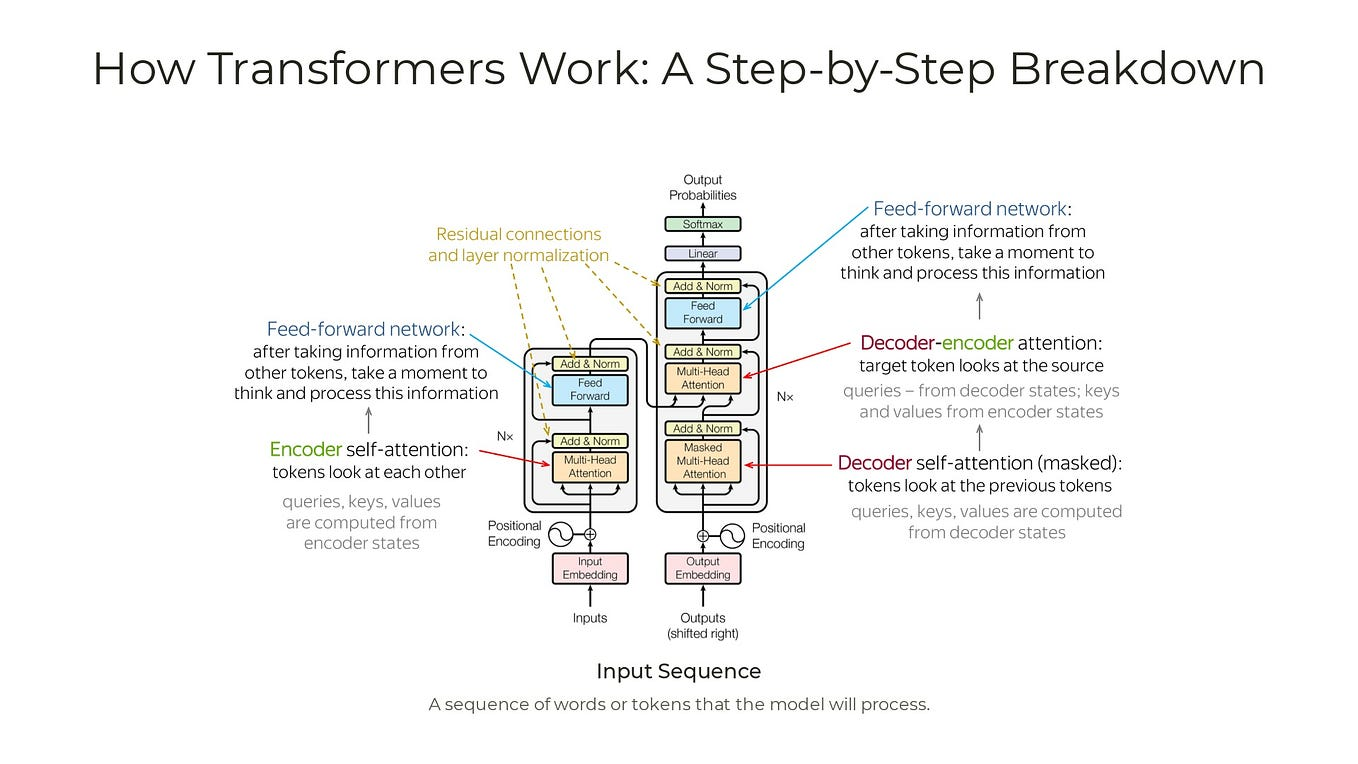

---
# Why It Matters

* Captures long-range dependencies 
* Fully parallelizable 
* More powerful than LSTM 

---

# Simple Example

Sentence:

```python
"The animal didn't cross the street because it was tired"
```

What does **"it"** refer to?

* "animal"?
* "street"?

---

### Self-Attention:

* Connects "it" → "animal" 

---

# Import Libraries

In [6]:
import torch
import torch.nn as nn
from torch.nn.utils.rnn import pad_sequence

# Self-Attention Layer

In [7]:
class SelfAttention(nn.Module):
    def __init__(self, embed_dim):
        super().__init__()
        
        self.query = nn.Linear(embed_dim, embed_dim)
        self.key   = nn.Linear(embed_dim, embed_dim)
        self.value = nn.Linear(embed_dim, embed_dim)

    def forward(self, x):
        Q = self.query(x)
        K = self.key(x)
        V = self.value(x)

        # Attention scores
        scores = torch.matmul(Q, K.transpose(-2, -1))
        
        # Scale
        scores = scores / (Q.shape[-1] ** 0.5)

        weights = torch.softmax(scores, dim=-1)

        output = torch.matmul(weights, V)

        return output, weights

In [8]:
sentences = [
    "i love nlp",
    "nlp is powerful"
]

words = set(" ".join(sentences).split())
word2idx = {word: i for i, word in enumerate(words)}

def encode(sentence):
    return [word2idx[word] for word in sentence.split()]

encoded = [torch.tensor(encode(s)) for s in sentences]
padded = pad_sequence(encoded, batch_first=True)

embed_dim = 8

embedding = nn.Embedding(
    num_embeddings=len(word2idx),
    embedding_dim=embed_dim
)

x = embedding(padded)

In [9]:
attention_layer = SelfAttention(embed_dim)

# Visualization / Results

In [11]:
sentence_idx = 0
tokens = sentences[sentence_idx].split()

attn = weights[sentence_idx].detach().numpy()

print("Attention Matrix:\n")
for i, row in enumerate(attn):
    print(f"{tokens[i]:>10} → {row[:len(tokens)]}")

Attention Matrix:

         i → [0.3136651 0.216515  0.4698199]
      love → [0.3518167  0.33230618 0.31587705]
       nlp → [0.310235   0.24977419 0.43999076]


---

## Meaning:

Each word attends to every other word

---

# Limitations

- Computationally expensive
- Needs lots of data
- Harder to understand initially

---

# Mini Summary

* Transformers = Attention only
* No recurrence (no LSTM)
* Uses Q, K, V mechanism
* Processes all words simultaneously

---

# Connection to Previous Notebook

* Before: Attention + LSTM
* Now: Attention ONLY

---

# BIG TAKEAWAY

```text
RNN → sequence
LSTM → memory
Attention → focus
Transformer → full attention system
```

---